# 03 - Mainnet CLMM

Concentrated-liquidity AMM analysis. This notebook is intentionally separate from CPMM because CLMM needs tick/active-liquidity state and cannot reuse the CPMM closed-form baseline.

Current inputs:
- `results/historical_clmm_decoded.csv` — decoded historical CLMM swap observations
- `results/historical_clmm_swaps_status.csv` — inclusion/exclusion ledger
- `results/historical_clmm_pipeline_summary.csv` — collection/decode funnel
- `results/historical_clmm_live_swaps.csv` — live-discovered CLMM swaps for short archive windows
- `results/historical_clmm_live_snapshots.csv` — repeated snapshots of live watchlisted CLMM accounts
- `results/historical_clmm_live_candidates.csv` — readiness filter over live decoded swaps

Attack-evaluation input:
- `results/historical_clmm_candidates.csv` — CLMM attack evaluation rows; rejected rows remain useful as methodology/status evidence


## Load data


In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "helpers").exists():
        sys.path.insert(0, str(candidate))
        break
    if (candidate / "notebooks" / "helpers").exists():
        sys.path.insert(0, str(candidate / "notebooks"))
        break

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from helpers import (
    best_conditions,
    blocker_table,
    data_readiness,
    find_repo_root,
    historical_counterfactual_summary,
    hypothesis_scorecard,
    load_inputs,
    plot_realized_heatmap,
    plot_sensitivity_lines,
)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

ROOT = find_repo_root()
inputs = load_inputs(ROOT)

clmm = inputs["frames"]["historical_clmm"]
clmm_decoded = inputs["frames"]["historical_clmm_decoded"]
clmm_status = inputs["frames"]["historical_clmm_swaps_status"]
clmm_summary = inputs["frames"]["historical_clmm_pipeline_summary"]
clmm_state_probe = inputs["frames"]["historical_clmm_state_probe"]
clmm_live_swaps = inputs["frames"]["historical_clmm_live_swaps"]
clmm_live_snapshots = inputs["frames"]["historical_clmm_live_snapshots"]
clmm_live_candidates = inputs["frames"]["historical_clmm_live_candidates"]
cpmm = inputs["frames"]["historical_cpmm"]

display(data_readiness(ROOT, inputs, [
    "historical_clmm_decoded",
    "historical_clmm_swaps_status",
    "historical_clmm_pipeline_summary",
    "historical_clmm_state_probe",
    "historical_clmm_live_swaps",
    "historical_clmm_live_snapshots",
    "historical_clmm_live_candidates",
    "historical_clmm",
    "historical_cpmm",
]))


/Users/piotrgasiorek/Studia/magisterka/notebooks/helpers/loading.py:27: DtypeWarning: Columns (0: error) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,dataset,file,rows,columns,ready_for_final_numbers,note
0,historical_clmm_decoded,results/historical_clmm_decoded.csv,4,29,False,decode coverage only; not profitability evidence
1,historical_clmm_swaps_status,results/historical_clmm_swaps_status.csv,50,16,True,ok
2,historical_clmm_pipeline_summary,results/historical_clmm_pipeline_summary.csv,2,7,True,ok
3,historical_clmm_state_probe,results/historical_clmm_state_probe.csv,4,22,False,state requirements only; not profitability evi...
4,historical_clmm_live_swaps,results/clmm_24h_sunday/historical_clmm_live_s...,254833,22,True,ok
5,historical_clmm_live_snapshots,results/clmm_24h_sunday/historical_clmm_live_s...,194146,11,True,ok
6,historical_clmm_live_candidates,results/clmm_24h_sunday/historical_clmm_live_c...,53747,29,True,ok
7,historical_clmm,results/clmm_24h_sunday/historical_clmm_candid...,53747,44,True,ok
8,historical_cpmm,results/cpmm_24h_sunday/historical_cpmm_candid...,6719,51,False,legacy schema: regenerate CSV


## Scope check


In [2]:
if not clmm.empty:
    if "model_status" in clmm:
        display(clmm["model_status"].value_counts().rename_axis("model_status").reset_index(name="rows"))
    if "rejection_reason" in clmm:
        display(clmm["rejection_reason"].fillna("evaluated").value_counts().rename_axis("rejection_reason").reset_index(name="rows"))
    display(historical_counterfactual_summary(clmm))
elif not clmm_decoded.empty:
    display(Markdown(
        f"Decoded `{len(clmm_decoded)}` CLMM swap observation(s), but no counterfactual candidate CSV exists yet. "
        "This is expected until historical PoolState/tick-array pre-state and CLMM replay validation are implemented."
    ))
    display(clmm_summary)
    if not clmm_state_probe.empty:
        display(clmm_state_probe[[
            "pool_label",
            "slot",
            "instruction_index",
            "required_account_count",
            "current_probe_slot",
            "current_pool_state_ok",
            "current_amm_config_ok",
            "current_tick_arrays_ok",
            "historical_state_available",
            "candidate_ready",
        ]].head(20))
    display(
        clmm_decoded[[
            "pool_label",
            "slot",
            "signature",
            "instruction_index",
            "swap_variant",
            "direction",
            "amount_in",
            "actual_amount_out",
            "historical_state_status",
        ]].head(20)
    )
else:
    display(Markdown(
        "No decoded CLMM observations exist yet. Run `cargo run -p fork --bin historical_clmm -- --pool clmm_wsol_usdc --limit-per-pool 50 run-all`."
    ))
    if not clmm_status.empty:
        display(clmm_status["analysis_status"].value_counts().rename_axis("analysis_status").reset_index(name="rows"))

if not clmm_live_swaps.empty:
    display(Markdown(
        f"Live collector observed `{len(clmm_live_swaps)}` signature row(s). "
        "Rows become useful for candidate construction only when all required accounts were known before discovery and a previous snapshot exists."
    ))
    display(clmm_live_swaps["status"].value_counts().rename_axis("status").reset_index(name="rows"))
    if not clmm_live_snapshots.empty:
        display(clmm_live_snapshots["account_role"].value_counts().rename_axis("account_role").reset_index(name="snapshots"))

if not clmm_live_candidates.empty:
    ready = clmm_live_candidates["live_candidate_ready"].astype(str).str.lower().isin(["true", "1"])
    display(Markdown(f"Live CLMM readiness rows: `{len(clmm_live_candidates)}`, ready: `{int(ready.sum())}`."))
    if "rejection_reason" in clmm_live_candidates:
        display(clmm_live_candidates.loc[~ready, "rejection_reason"].value_counts().rename_axis("rejection_reason").reset_index(name="rows"))


,model_status,rows
0,rejected,33679
1,evaluated,20068


,rejection_reason,rows
0,previous_snapshot_after_block_time,33083
1,best_attempt_unprofitable,19352
2,evaluated,582
3,unsupported_base_output,307
4,below_candidate_threshold,155
5,best_attempt_infeasible,134
6,victim_replay_mismatch,91
7,missing_tick_array_snapshot,29
8,missing_previous_snapshot,14


,pool_type,pool_label,rows,profitable_rate,feasible_rate,realized_rate,median_net_profit
0,raydium_clmm,clmm_usdc_usdt,1440,0.202778,0.202778,0.202778,0.0
1,raydium_clmm,clmm_wsol_usdc,29785,0.000034,0.000034,0.000034,0.0
2,raydium_clmm,clmm_wsol_usdt,22522,0.012832,0.011411,0.011411,0.0


Live collector observed `254833` signature row(s). Rows become useful for candidate construction only when all required accounts were known before discovery and a previous snapshot exists.

,status,rows
0,tx_failed,174054
1,decoded,53747
2,no_single_target_swap,19229
3,decode_failed,7803


,account_role,snapshots
0,remaining_tick_account,157435
1,observation_state,12237
2,amm_config,12237
3,pool_state,12237


Live CLMM readiness rows: `53747`, ready: `20621`.

,rejection_reason,rows
0,previous_snapshot_after_block_time,33083
1,missing_tick_array_snapshot,29
2,missing_previous_snapshot,14


## Required CLMM candidate fields


In [3]:
required = pd.DataFrame([
    {"field": "pool_type", "why": "distinguish raydium_clmm/orca_whirlpool from cpmm"},
    {"field": "pool_label, pool_address", "why": "group results by selected pool"},
    {"field": "slot, signature, instruction_index", "why": "trace every counterfactual row back to a historical swap"},
    {"field": "amount_in, min_amount_out, actual_amount_out", "why": "victim size and slippage bound"},
    {"field": "sqrt_price_x64_before, liquidity_before, tick_current_before", "why": "CLMM state at victim pre-state"},
    {"field": "tick_arrays_before", "why": "needed for executable CLMM swap simulation across ticks"},
    {"field": "fee_rate, protocol_fee_rate", "why": "fee-aware profitability"},
    {"field": "tx_cost_per_leg", "why": "net profit, not just gross extraction"},
])
display(required)


,field,why
0,pool_type,distinguish raydium_clmm/orca_whirlpool from cpmm
1,"pool_label, pool_address",group results by selected pool
2,"slot, signature, instruction_index",trace every counterfactual row back to a histo...
3,"amount_in, min_amount_out, actual_amount_out",victim size and slippage bound
4,"sqrt_price_x64_before, liquidity_before, tick_...",CLMM state at victim pre-state
5,tick_arrays_before,needed for executable CLMM swap simulation acr...
6,"fee_rate, protocol_fee_rate",fee-aware profitability
7,tx_cost_per_leg,"net profit, not just gross extraction"


## CPMM vs CLMM comparison


In [4]:
if clmm.empty or cpmm.empty:
    display(Markdown("Counterfactual CPMM vs CLMM comparison waits for both historical CPMM and CLMM candidate outputs."))
    if not clmm_decoded.empty:
        display(Markdown("CLMM decode coverage is available, but it is not profitability evidence yet."))
else:
    cpmm_summary = historical_counterfactual_summary(cpmm).assign(family="CPMM")
    clmm_candidate_summary = historical_counterfactual_summary(clmm).assign(family="CLMM")
    display(pd.concat([cpmm_summary, clmm_candidate_summary], ignore_index=True))


,pool_type,pool_label,rows,profitable_rate,feasible_rate,realized_rate,median_net_profit,family
0,raydium_cpmm,wsol_idle,367,0.070845,0.070845,0.070845,0.0,CPMM
1,raydium_cpmm,wsol_ready,3920,0.012245,0.012245,0.012245,0.0,CPMM
2,raydium_cpmm,wsol_useless,2432,0.009868,0.009868,0.009868,0.0,CPMM
3,raydium_clmm,clmm_usdc_usdt,1440,0.202778,0.202778,0.202778,0.0,CLMM
4,raydium_clmm,clmm_wsol_usdc,29785,0.000034,0.000034,0.000034,0.0,CLMM
5,raydium_clmm,clmm_wsol_usdt,22522,0.012832,0.011411,0.011411,0.0,CLMM


## Replay validation

`replay_error_bps = |fair_amount_out - actual_amount_out| / actual_amount_out
* 10000`. The pipeline rejects rows above the configured tolerance
(`--replay-tolerance-bps`, default 100). Stats below are over the
`evaluated` rows that passed the tolerance, plus a count of rejected
outliers. See `.docs/audits/2026-05-clmm-model-validation.md`.


,n_with_replay,n_evaluated,median_bps,mean_bps,p95_bps,max_bps,outliers_rejected
0,20159,20068,1.0,1.995515,7.0,100.0,91


### Replay outliers rejected by the pipeline

,pool_label,signature,direction,amount_in,actual_amount_out,fair_amount_out,replay_error_bps
110,clmm_wsol_usdt,3wXrLeo8QRsuAVBWDrKf2bn6ABjAdGRDur4DVGxFKWQTUS...,base_input,8084147782,703201427,4.677078e+08,3348.0
443,clmm_wsol_usdt,4Hbi7SBcFvLydvYrnspSBWAU1xbMDufkeLX7xqQT449JMZ...,base_input,11179297902,972609018,7.211201e+08,2585.0
564,clmm_wsol_usdt,5rKd6n8CEYvN3LQGeKdDyykMiZjiGfRK2Xbg7gHNh2ce3f...,base_input,7344275210,638351182,1.681947e+08,7365.0
1273,clmm_wsol_usdc,21ULJ5goGop2ELK2kgBpyrUAyMWZXkX2vdc5k2J3vfsriS...,base_input,644434175,7423189320,6.619946e+09,1082.0
1834,clmm_wsol_usdt,61CKSAnfxPVEv5LNGoxKbkt61v3zKgmS8rPNUAGz369rRU...,base_input,586606231,6750346949,6.377819e+09,551.0
...,...,...,...,...,...,...,...
52077,clmm_wsol_usdt,5s4HUgNkXNd3TNXpsEd4JXiYefgqtz4k25ppjmCCi1vXXa...,base_input,8197450900,698577717,3.853372e+08,4483.0
52331,clmm_wsol_usdt,4Ma5zYxivf6krgFYE7UXrpVUDkLj5ruGV5qfadQPBVqfAU...,base_input,609323430,7140280548,5.238512e+09,2663.0
52374,clmm_wsol_usdc,5rU8zMNE8HYYMSBXjJ11GTRaWyZn4CtbqNaYwGc8oaEXT4...,base_input,6532291499,556905693,5.486092e+08,148.0
52886,clmm_wsol_usdc,2h3N4ioFiWC4B8kwKtLruFEmX3DA9vw3vP476Z5H96uCsa...,base_input,221853501858,18890126533,1.188678e+10,3707.0


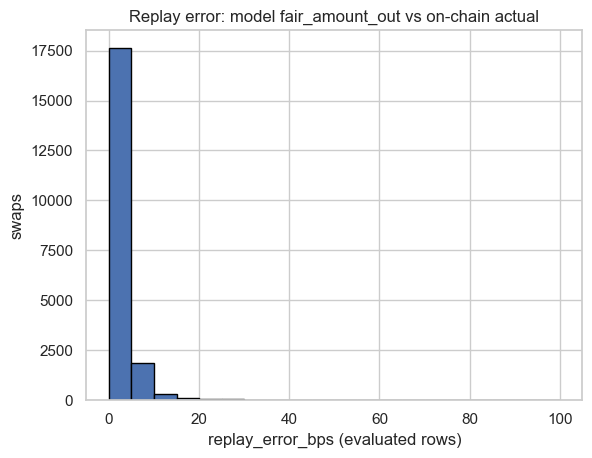

In [5]:
from helpers.clmm_attacks import replay_validation_summary

if clmm.empty or "replay_error_bps" not in clmm.columns:
    display(Markdown("No `replay_error_bps` column — re-run `evaluate-live-attacks`."))
else:
    stats = replay_validation_summary(clmm)
    display(pd.DataFrame([stats]))
    err = pd.to_numeric(
        clmm.loc[clmm["model_status"].astype(str).eq("evaluated"), "replay_error_bps"],
        errors="coerce",
    ).dropna()
    if not err.empty:
        ax = err.plot(kind="hist", bins=20, edgecolor="black")
        ax.set_xlabel("replay_error_bps (evaluated rows)")
        ax.set_ylabel("swaps")
        ax.set_title("Replay error: model fair_amount_out vs on-chain actual")
    if (clmm.get("rejection_reason", "") == "victim_replay_mismatch").any():
        outliers = clmm[clmm["rejection_reason"] == "victim_replay_mismatch"][
            ["pool_label", "signature", "direction", "amount_in", "actual_amount_out", "fair_amount_out", "replay_error_bps"]
        ]
        display(Markdown("### Replay outliers rejected by the pipeline"))
        display(outliers)


## Best-attempt diagnostics

Why does the live CLMM evaluator return `0` profitable rows on this sample?
The grid search now keeps the highest-`net_profit` attempt regardless of
profitability, so the `best_attempt_*` columns expose the failure mode for
every evaluated candidate (fee drag, victim slippage breach, victim too
small). `rejection_reason` distinguishes `no_grid_result`,
`best_attempt_infeasible`, and `best_attempt_unprofitable`.


In [6]:
from helpers.clmm_attacks import (
    attach_diagnostics,
    rejection_breakdown,
    best_attempt_summary,
    fee_drag_vs_gross,
)

if clmm.empty or "best_attempt_net_profit" not in clmm.columns:
    display(Markdown(
        "No `best_attempt_*` columns in `historical_clmm_candidates.csv`. "
        "Re-run `evaluate-live-attacks` with the current `attack.rs` to populate them."
    ))
else:
    diag = attach_diagnostics(clmm)
    display(Markdown(
        f"Evaluated rows: `{int(diag['evaluated'].sum())}` of `{len(diag)}`. "
        f"Profitable: `{int(diag.get('attack_profitable', False).astype(bool).sum())}`."
    ))
    display(rejection_breakdown(diag))
    display(best_attempt_summary(diag))
    drag_series = fee_drag_vs_gross(diag)
    if not drag_series.empty:
        display(Markdown(
            f"`best_attempt_gross_profit - 2*tx_cost_per_leg` over evaluated rows: "
            f"min `{drag_series.min():,.0f}`, median `{drag_series.median():,.0f}`, "
            f"max `{drag_series.max():,.0f}`, share <= 0: "
            f"`{(drag_series <= 0).mean():.0%}`."
        ))


Evaluated rows: `20068` of `53747`. Profitable: `582`.

,rejection_reason,rows,label
0,previous_snapshot_after_block_time,33083,previous_snapshot_after_block_time
1,best_attempt_unprofitable,19352,best attempt feasible but net profit <= 0
2,evaluated_profitable,582,evaluated_profitable
3,unsupported_base_output,307,unsupported_base_output
4,below_candidate_threshold,155,below_candidate_threshold
5,best_attempt_infeasible,134,best attempt breached victim slippage tolerance
6,victim_replay_mismatch,91,victim_replay_mismatch
7,missing_tick_array_snapshot,29,missing_tick_array_snapshot
8,missing_previous_snapshot,14,missing_previous_snapshot


,bucket,rows,median_best_net_profit,median_best_gross_profit,median_victim_loss,median_victim_slippage_bps,median_best_frontrun,median_victim_amount_in
0,infeasible,134,-1.0,-1.0,1.0,0.0,6.998000e+03,1.500081e+09
1,profitable,582,22305809.5,22305809.5,389251088.5,1298.0,1.593771e+12,2.000000e+09
2,unprofitable_feasible,19352,-1.0,-1.0,0.0,0.0,4.272000e+03,3.000000e+08


`best_attempt_gross_profit - 2*tx_cost_per_leg` over evaluated rows: min `-1,446,354`, median `-1`, max `63,035,213,725`, share <= 0: `97%`.

## Profitability landscape

Outcome buckets per pool, with the capital-efficiency and slippage-breach
caveats called out for the profitable subset. See
`.docs/audits/2026-05-clmm-optimizer-port.md` for the discussion of why
the headline profitable share should not be quoted without these filters.


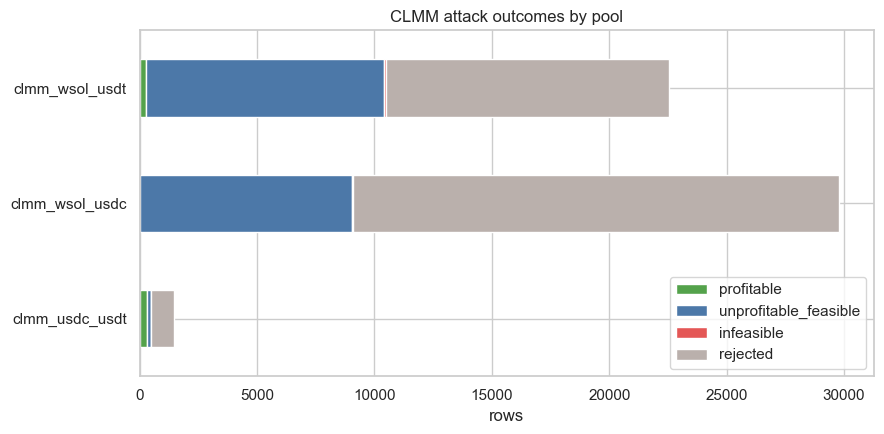

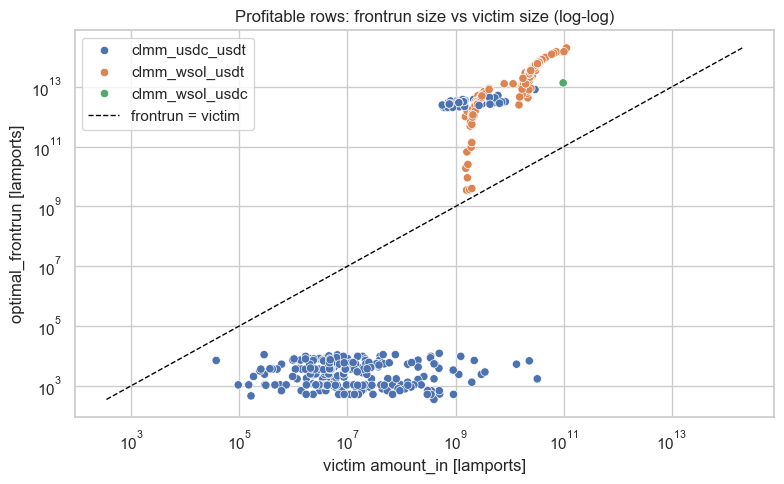

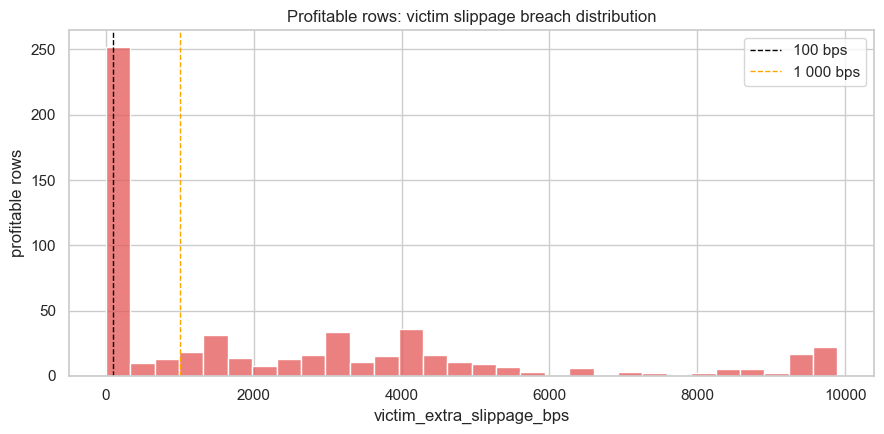

In [7]:
from helpers.clmm_attacks import (
    plot_attempt_buckets_by_pool,
    plot_frontrun_vs_victim,
    plot_victim_slippage_breach,
)

if not clmm.empty and "best_attempt_net_profit" in clmm.columns:
    fig = plot_attempt_buckets_by_pool(clmm)
    if fig is not None:
        plt.show()
    fig = plot_frontrun_vs_victim(clmm)
    if fig is not None:
        plt.show()
    fig = plot_victim_slippage_breach(clmm)
    if fig is not None:
        plt.show()


## Thesis-ready takeaways


In [8]:
if clmm.empty:
    lines = [
        "- CLMM profitability remains an empirical gap, not a result.",
        f"- Decoded CLMM observations available: `{len(clmm_decoded)}` rows.",
        f"- CLMM state probe rows available: `{len(clmm_state_probe)}` rows.",
        "- Next blocker: historical PoolState/tick-array pre-state and victim-swap replay validation.",
    ]
    display(Markdown("\n".join(lines)))
else:
    display(Markdown(f"- Historical CLMM counterfactual candidates loaded: `{len(clmm)}` rows."))


- Historical CLMM counterfactual candidates loaded: `53747` rows.